# UrbanFloodBench Baseline Workflow

This notebook is the team-friendly entry point for:

- loading UrbanFloodBench data
- building cleaned node-level features
- running persistence and random forest baselines
- inspecting validation metrics

The notebook calls reusable code from `src/urbanflood`, so the team can collaborate in notebooks without duplicating logic.

In [33]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve().parent
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

ROOT

PosixPath('/')

In [4]:
!git clone https://github.com/Hiro208/UrbanFlood.git

import sys
sys.path.append('/content/UrbanFlood/src')

import pandas as pd

from urbanflood.dataset import load_model_assets
from urbanflood.features import build_training_dataset, clean_training_dataset
from urbanflood.baselines import (
    event_based_split,
    get_feature_columns,
    run_persistence_baseline,
    run_random_forest_baseline,
    evaluate_baselines,
)

pd.set_option('display.max_columns', 200)
print("urbanflood import success")

Cloning into 'UrbanFlood'...
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 18 (delta 0), reused 18 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (18/18), 13.17 KiB | 13.17 MiB/s, done.
urbanflood import success


## Paths And Debug Settings

In [34]:

from pathlib import Path

DATA_DIR = Path('/content/drive/MyDrive/UrbanFloodData')
MAX_EVENTS_PER_MODEL = 2
MAX_TRAIN_ROWS = 50000
LAG_STEPS = (1, 2, 3, 5, 10)
RAIN_WINDOWS = (3, 5, 10)

DATA_DIR

PosixPath('/content/drive/MyDrive/UrbanFloodData')

## Build Training Dataset

In [36]:
frames = []
for model_id in (1, 2):
    assets = load_model_assets(DATA_DIR, model_id=model_id, split='train')
    frame = build_training_dataset(
        assets,
        lag_steps=LAG_STEPS,
        rain_windows=RAIN_WINDOWS,
        max_events=MAX_EVENTS_PER_MODEL,
    )
    frame = clean_training_dataset(frame)
    print(f'model {model_id}: {len(frame):,} rows')
    frames.append(frame)

dataset = pd.concat(frames, ignore_index=True)
dataset.shape

model 1: 1,108,701 rows
model 2: 1,349,100 rows


(2457801, 83)

In [38]:
dataset.head()

,timestep,node_idx,water_level,node_aux_flow,model_id,event_id,node_type,position_x,position_y,depth,invert_elevation,surface_elevation,base_area,edge_in_flow_mean,edge_in_flow_max,edge_in_flow_min,edge_in_velocity_mean,edge_in_velocity_max,edge_in_velocity_min,edge_out_flow_mean,edge_out_flow_max,edge_out_flow_min,edge_out_velocity_mean,edge_out_velocity_max,edge_out_velocity_min,edge_upstream_water_level_mean,edge_upstream_water_level_max,edge_upstream_water_level_min,edge_downstream_water_level_mean,edge_downstream_water_level_max,edge_downstream_water_level_min,surface_paired_water_level_mean,surface_paired_water_level_max,surface_paired_water_level_min,surface_paired_rainfall_mean,surface_paired_rainfall_max,surface_paired_rainfall_min,surface_paired_water_volume_mean,surface_paired_water_volume_max,surface_paired_water_volume_min,effective_area,reference_elevation,rainfall,target_water_level,target_delta_water_level,delta_water_level,water_level_lag_1,delta_water_level_lag_1,rainfall_lag_1,water_level_lag_2,delta_water_level_lag_2,rainfall_lag_2,water_level_lag_3,delta_water_level_lag_3,rainfall_lag_3,water_level_lag_5,delta_water_level_lag_5,rainfall_lag_5,water_level_lag_10,delta_water_level_lag_10,rainfall_lag_10,rainfall_sum_3,rainfall_mean_3,rainfall_sum_5,rainfall_mean_5,rainfall_sum_10,rainfall_mean_10,cumulative_rainfall,timestep_index,water_level_above_reference,is_raining,water_level_to_area_ratio,water_volume,area,roughness,min_elevation,elevation,aspect,curvature,flow_accumulation,pipe_paired_water_level_mean,pipe_paired_water_level_max,pipe_paired_water_level_min
0,0.0,0,294.87430,0.0,1,1,1,802465.6,349898.84,8.977997,292.342,301.32,12.56,16.837931,31.815710,1.860152,4.970807,6.481443,3.460171,33.611320,33.611320,33.611320,8.418276,8.418276,8.418276,296.187460,296.18870,296.18622,288.22095,288.22095,288.22095,300.070648,300.070648,300.070648,0.143333,0.143333,0.143333,1.180193,1.180193,1.180193,12.56,292.342,0.143333,294.98570,0.11140,0.00000,0.00000,0.00000,0.000000,0.00000,0.00000,0.000000,0.0000,0.0000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.143333,0.143333,0.143333,0.143333,0.143333,0.143333,0.143333,0,2.53230,1,0.201616,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0,294.98570,0.0,1,1,1,802465.6,349898.84,8.977997,292.342,301.32,12.56,17.313536,32.773335,1.853738,5.056079,6.676529,3.435629,34.621025,34.621025,34.621025,8.554404,8.554404,8.554404,296.282965,296.37643,296.18950,288.25427,288.25427,288.25427,300.070374,300.070374,300.070374,0.136667,0.136667,0.136667,1.178370,1.178370,1.178370,12.56,292.342,0.136667,295.00534,0.01964,0.11140,294.87430,0.00000,0.143333,0.00000,0.00000,0.000000,0.0000,0.0000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.280000,0.140000,0.280000,0.140000,0.280000,0.140000,0.280000,1,2.64370,1,0.210486,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2.0,0,295.00534,0.0,1,1,1,802465.6,349898.84,8.977997,292.342,301.32,12.56,17.397679,32.941055,1.854302,5.071252,6.710697,3.431807,34.790653,34.790653,34.790653,8.577585,8.577585,8.577585,296.300165,296.41030,296.19003,288.25964,288.25964,288.25964,300.070435,300.070435,300.070435,0.136667,0.136667,0.136667,1.178905,1.178905,1.178905,12.56,292.342,0.136667,295.02298,0.01764,0.01964,294.98570,0.11140,0.136667,294.87430,0.00000,0.143333,0.0000,0.0000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.416667,0.138889,0.416667,0.138889,0.416667,0.138889,0.416667,2,2.66334,1,0.212049,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3.0,0,295.02298,0.0,1,1,1,802465.6,349898.84,8.977997,292.342,301.32,12.56,17.553244,33.064080,2.042407,5.138633,6.735759,3.541506,35.096320,35.096320,35.096320,8.619795,8.619795,8.619795,296.327085,296.43850,296.21567,288.26910,288.26910,288.26910,300.070404,300.070404,300.070404,0.136667,0.136667,0.136667,1.178556,1.178556,1.178556,12.56,292.342,0.136667,295.02390,0.00092,0.01764,295.00534,0.01964,0.136667,294.98570,0.11140,0.136667,294.8743,0.0000,0.143333,0.0,0.0,0.0,0.0,0.0,0.0,0.410000,0.136667,0.553333,0.138333,0.553333,0.138333,0.553

## Event-Based Validation Split

In [37]:
train_df, val_df = event_based_split(dataset, validation_fraction=0.2)
if len(train_df) > MAX_TRAIN_ROWS:
    train_df = train_df.sample(MAX_TRAIN_ROWS, random_state=42)

feature_columns = get_feature_columns(
    train_df,
    drop_columns=('target_water_level', 'target_delta_water_level', 'timestamp'),
)

train_df.shape, val_df.shape, len(feature_columns)

((50000, 83), (1678920, 83), 76)

## Run Baselines

In [39]:
persistence_pred = run_persistence_baseline(val_df)

rf_pred, rf_model = run_random_forest_baseline(
    train_df=train_df,
    val_df=val_df,
    feature_columns=feature_columns,
    n_estimators=300,
    max_depth=18,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)

metrics = evaluate_baselines([persistence_pred, rf_pred])
metrics

,model_name,rmse,mae,num_rows
0,persistence,0.022982,0.008444,1678920
1,random_forest,0.025243,0.009622,1678920


## Inspect Predictions

In [40]:
rf_pred.head()

,model_id,event_id,node_type,node_idx,timestep,target_water_level,prediction,model_name
0,1,2,1,0,0.0,292.80490,291.664905,random_forest
1,1,2,1,0,1.0,292.78700,292.275850,random_forest
2,1,2,1,0,2.0,292.77158,292.521654,random_forest
3,1,2,1,0,3.0,292.76025,292.490809,random_forest
4,1,2,1,0,4.0,292.75177,292.419370,random_forest


hdr

LSTM

In [43]:
import numpy as np

TARGET = 'target_water_level'

feature_columns = get_feature_columns(
    train_df,
    drop_columns=('target_water_level', 'target_delta_water_level', 'timestamp'),
)

X_train = train_df[feature_columns].values
y_train = train_df[TARGET].values

X_val = val_df[feature_columns].values
y_val = val_df[TARGET].values

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)

X_train: (50000, 76)
X_val: (1678920, 76)


In [44]:
X_train_lstm = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_val_lstm = X_val.reshape(X_val.shape[0], 1, X_val.shape[1])

print("LSTM input shape:", X_train_lstm.shape)

LSTM input shape: (50000, 1, 76)


In [45]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

lstm_model = Sequential([
    LSTM(64, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

lstm_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        36,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,209 (149.25 KB)

 Trainable params: 38,209 (149.25 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_train_lstm, y_train,
    validation_data=(X_val_lstm, y_val),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 55s 67ms/step - loss: 28633.5977 - mae: 130.9158 - val_loss: 13932.7285 - val_mae: 115.2125
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 78s 62ms/step - loss: 10863.5254 - mae: 97.0590 - val_loss: 6107.2700 - val_mae: 76.5171
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 48s 62ms/step - loss: 5847.8779 - mae: 59.8474 - val_loss: 1852.3651 - val_mae: 40.8794
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 50s 64ms/step - loss: 4563.6875 - mae: 44.3945 - val_loss: 950.1797 - val_mae: 28.6370
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 48s 61ms/step - loss: 4368.7729 - mae: 42.1214 - val_loss: 883.7810 - val_mae: 27.2321
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 48s 62ms/step - loss: 4232.1084 - mae: 40.6061 - val_loss: 881.1146 - val_mae: 27.3644
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 49s 63ms/step - loss: 4249.0942 - mae: 39.9226 - val_loss: 883.8403 - val_mae: 27.3664
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 63ms/step - loss: 4185.6689 - mae: 38.7683 - val_loss: 886.

In [47]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np

lstm_pred = lstm_model.predict(X_val_lstm).flatten()

lstm_metrics = pd.DataFrame([{
    'model_name': 'LSTM',
    'rmse': np.sqrt(mean_squared_error(y_val, lstm_pred)),
    'mae': mean_absolute_error(y_val, lstm_pred),
    'r2': r2_score(y_val, lstm_pred),
}])

print(lstm_metrics)

52467/52467 ━━━━━━━━━━━━━━━━━━━━ 71s 1ms/step
  model_name       rmse        mae        r2
0       LSTM  29.683713  27.364378  0.954375


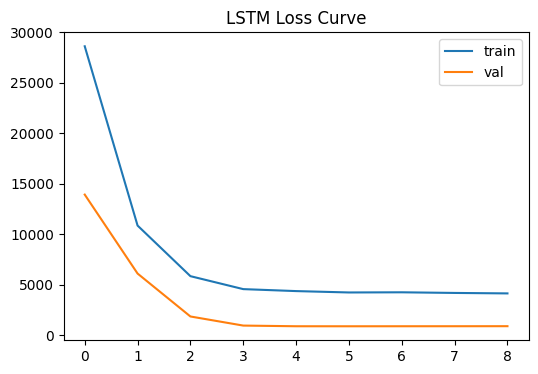

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('LSTM Loss Curve')
plt.legend()
plt.show()

CNN-LSTM

In [49]:
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val_cnn = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)

print("X_train_cnn:", X_train_cnn.shape)
print("X_val_cnn:", X_val_cnn.shape)

X_train_cnn: (50000, 76, 1)
X_val_cnn: (1678920, 76, 1)


In [50]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

cnn_lstm_model = Sequential([
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu',
        input_shape=(X_train_cnn.shape[1], X_train_cnn.shape[2])
    ),
    MaxPooling1D(pool_size=2),

    LSTM(32),
    Dropout(0.2),

    Dense(16, activation='relu'),
    Dense(1)
])

cnn_lstm_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

cnn_lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 74, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 37, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,217 (51.63 KB)

 Trainable params: 13,217 (51.63 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
early_stop_cnn_lstm = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_cnn_lstm = cnn_lstm_model.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop_cnn_lstm],
    verbose=1
)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 226s 289ms/step - loss: 487.5507 - mae: 14.0594 - val_loss: 118.4242 - val_mae: 6.7123
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 221s 282ms/step - loss: 458.0577 - mae: 13.4893 - val_loss: 101.8214 - val_mae: 6.1933
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 261s 282ms/step - loss: 437.2567 - mae: 12.9946 - val_loss: 108.6347 - val_mae: 6.2889
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 280s 358ms/step - loss: 429.9672 - mae: 12.6210 - val_loss: 101.8894 - val_mae: 6.0187
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 220s 281ms/step - loss: 409.7216 - mae: 12.2097 - val_loss: 109.2780 - val_mae: 6.3473


In [53]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np

cnn_lstm_pred = cnn_lstm_model.predict(X_val_cnn).flatten()

cnn_lstm_metrics = pd.DataFrame([{
    'model_name': 'CNN-LSTM',
    'rmse': np.sqrt(mean_squared_error(y_val, cnn_lstm_pred)),
    'mae': mean_absolute_error(y_val, cnn_lstm_pred),
    'r2': r2_score(y_val, cnn_lstm_pred),
}])

print(cnn_lstm_metrics)

52467/52467 ━━━━━━━━━━━━━━━━━━━━ 298s 6ms/step
  model_name       rmse       mae        r2
0   CNN-LSTM  10.090663  6.193304  0.994728


In [54]:
all_metrics = pd.concat([metrics, lstm_metrics, cnn_lstm_metrics], ignore_index=True)
all_metrics

,model_name,rmse,mae,num_rows,r2
0,persistence,0.022982,0.008444,1678920.0,NaN
1,random_forest,0.025243,0.009622,1678920.0,NaN
2,LSTM,29.683713,27.364378,NaN,0.954375
3,CNN-LSTM,10.090663,6.193304,NaN,0.994728


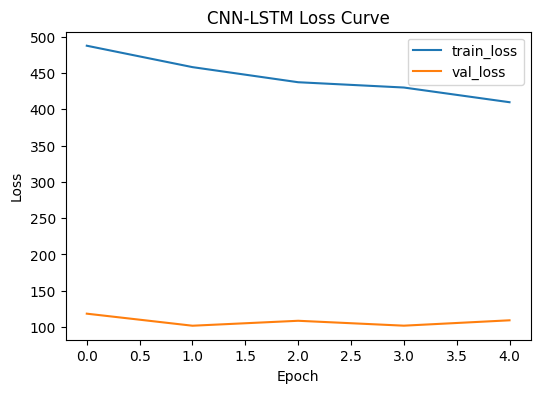

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(history_cnn_lstm.history['loss'], label='train_loss')
plt.plot(history_cnn_lstm.history['val_loss'], label='val_loss')
plt.title('CNN-LSTM Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()